In [1]:
import pickle
import glob
import pandas as pd
import matplotlib.pyplot as plt

features = ['inducedVertBreak', 'horzBreak', 'extension', 'relX', 'relZ', 'releaseVelocity', 'spinRate']

model_files = glob.glob('26_*.pkl')

importance_records = []

for path in model_files:
    # Extract pitch and side from filename, e.g. "26_FF_R.pkl"
    parts = path.replace('.pkl', '').split('_')
    pitch, side = parts[1], parts[2]

    with open(path, 'rb') as f:
        model = pickle.load(f)

    importances = model.booster_.feature_importance(importance_type='gain') 

    for feat, imp in zip(features, importances):
        importance_records.append({'pitch': pitch, 'side': side, 'feature': feat, 'importance': imp})

df_imp = pd.DataFrame(importance_records)
print(df_imp)

   pitch side           feature   importance
0     FC    R  inducedVertBreak  2580.243940
1     FC    R         horzBreak  2827.139599
2     FC    R         extension  2678.844215
3     FC    R              relX  2673.502321
4     FC    R              relZ  2722.144171
..   ...  ...               ...          ...
93    SL    L         extension  2540.021102
94    SL    L              relX  2709.996391
95    SL    L              relZ  2792.430396
96    SL    L   releaseVelocity  2750.695378
97    SL    L          spinRate  2786.356354

[98 rows x 4 columns]


In [2]:
df_imp.groupby('feature')['importance'].mean().sort_values(ascending=False)

feature
inducedVertBreak    3342.216018
releaseVelocity     3034.004159
horzBreak           2741.761223
relZ                2696.042164
relX                2676.676669
extension           2610.189561
spinRate            2600.808809
Name: importance, dtype: float64

In [3]:
df_imp[(df_imp['pitch'] == 'FA') & (df_imp['side'] == 'R')].sort_values('importance', ascending=False)

,pitch,side,feature,importance
7,FA,R,inducedVertBreak,11212.667403
12,FA,R,releaseVelocity,7621.532497
11,FA,R,relZ,4998.448929
10,FA,R,relX,4988.104068
8,FA,R,horzBreak,4898.482008
9,FA,R,extension,4413.257560
13,FA,R,spinRate,4106.559643


In [4]:
df_imp[(df_imp['pitch'] == 'FA') & (df_imp['side'] == 'L')].sort_values('importance', ascending=False)

,pitch,side,feature,importance
84,FA,L,inducedVertBreak,6013.662628
89,FA,L,releaseVelocity,5319.490303
85,FA,L,horzBreak,4373.175826
87,FA,L,relX,4034.032770
88,FA,L,relZ,3904.921798
86,FA,L,extension,3801.987658
90,FA,L,spinRate,3629.690682


In [5]:
df_imp[(df_imp['pitch'] == 'CU') & (df_imp['side'] == 'L')].sort_values('importance', ascending=False)

,pitch,side,feature,importance
63,CU,L,inducedVertBreak,2180.961257
68,CU,L,releaseVelocity,2162.169276
69,CU,L,spinRate,2121.504862
66,CU,L,relX,2058.730907
67,CU,L,relZ,2021.438981
64,CU,L,horzBreak,1967.049393
65,CU,L,extension,1948.793572


In [6]:
df_imp[(df_imp['pitch'] == 'SL') & (df_imp['side'] == 'L')].sort_values('importance', ascending=False)

,pitch,side,feature,importance
95,SL,L,relZ,2792.430396
97,SL,L,spinRate,2786.356354
96,SL,L,releaseVelocity,2750.695378
92,SL,L,horzBreak,2734.255860
94,SL,L,relX,2709.996391
91,SL,L,inducedVertBreak,2655.406161
93,SL,L,extension,2540.021102


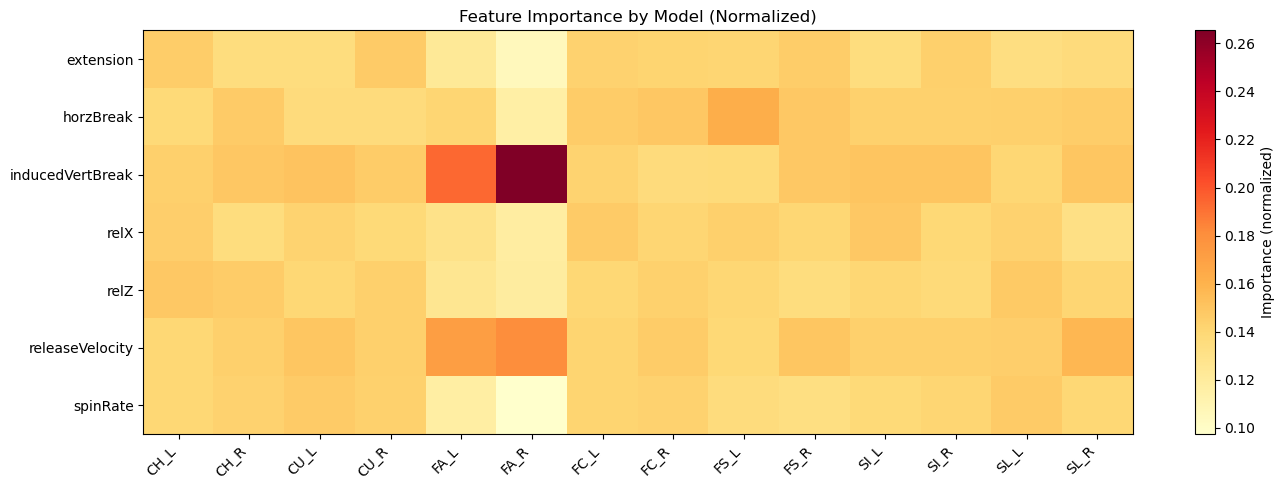

In [7]:
pivot = df_imp.pivot_table(index='feature', columns=['pitch', 'side'], values='importance')
pivot.columns = ['_'.join(c) for c in pivot.columns]

# Normalize each column to sum to 1
pivot_norm = pivot.div(pivot.sum(axis=0), axis=1)

fig, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(pivot_norm.values, aspect='auto', cmap='YlOrRd')
ax.set_xticks(range(len(pivot_norm.columns)))
ax.set_xticklabels(pivot_norm.columns, rotation=45, ha='right')
ax.set_yticks(range(len(pivot_norm.index)))
ax.set_yticklabels(pivot_norm.index)
plt.colorbar(im, ax=ax, label='Importance (normalized)')
plt.title('Feature Importance by Model (Normalized)')
plt.tight_layout()
plt.show()

In [11]:
pivot_norm = pivot.div(pivot.sum(axis=0), axis=1)